# SMS Spam Detection — Full NLP Pipeline (UCI SMS Spam Collection)
### NLP Course Project

**Objective:** Build a complete text-classification pipeline — from raw SMS messages to a trained spam classifier — covering text cleaning, tokenization, stopword removal, lemmatization, TF-IDF vectorization, model training, and evaluation.

**Dataset:** `SMSSpamCollection` — the well-known **UCI SMS Spam Collection** dataset: 5,572 real SMS messages (UK English), tab-separated as `label` (`ham`/`spam`) and `message` (raw text). This is a widely used academic benchmark for spam classification, containing general, natural spam/ham vocabulary rather than being tied to one narrow domain — which should make our model generalize better than a domain-specific dataset would.


## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay, PrecisionRecallDisplay)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 2. Load and Inspect the Data

In [2]:
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])
df['spam'] = (df['label'] == 'spam').astype(int)
print("Shape:", df.shape)
df.head()


Shape: (5572, 3)


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
 2   spam     5572 non-null   int64
dtypes: int64(1), str(2)
memory usage: 130.7 KB


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nFull duplicate rows:", df.duplicated().sum())
print("Duplicate messages:", df.duplicated(subset=['message']).sum())


Missing values:
 label      0
message    0
spam       0
dtype: int64

Full duplicate rows: 403
Duplicate messages: 403


**Handling duplicates:** As with any real-world SMS collection, some messages are repeated verbatim (e.g. identical spam blasts). We deduplicate on message text **before** the train/test split, so identical messages can't leak between the two sets and artificially inflate our scores.


In [5]:
df = df.drop_duplicates(subset=['message']).reset_index(drop=True)
print("Shape after deduplication:", df.shape)
print(df['spam'].value_counts(normalize=True).rename('proportion'))


Shape after deduplication: (5169, 3)
spam
0    0.87367
1    0.12633
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

### 3.1 Class Balance

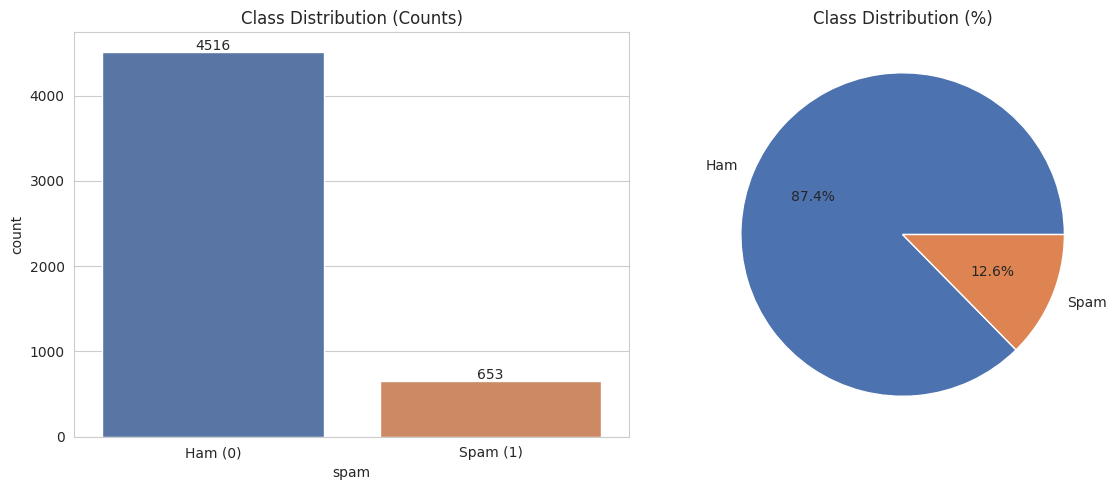

Imbalance ratio: 6.9 : 1


In [6]:
class_counts = df['spam'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='spam', data=df, hue='spam', legend=False, palette=['#4C72B0', '#DD8452'], ax=ax[0])
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(['Ham (0)', 'Spam (1)'])
ax[0].set_title('Class Distribution (Counts)')
for i, v in enumerate(class_counts.sort_index()):
    ax[0].text(i, v + 20, str(v), ha='center')

ax[1].pie(class_counts, labels=['Ham', 'Spam'], autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
ax[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.1f} : 1")


**Observation:** This dataset is imbalanced again — roughly 87% ham / 13% spam (~7:1), much closer to realistic real-world spam rates than the previous dataset. This means:
- Accuracy alone can be misleading (predicting "ham" for everything already scores ~87%).
- We use `class_weight='balanced'` for the models that support it, and lean on precision/recall/F1/ROC-AUC for evaluation.


### 3.2 Message Length Analysis

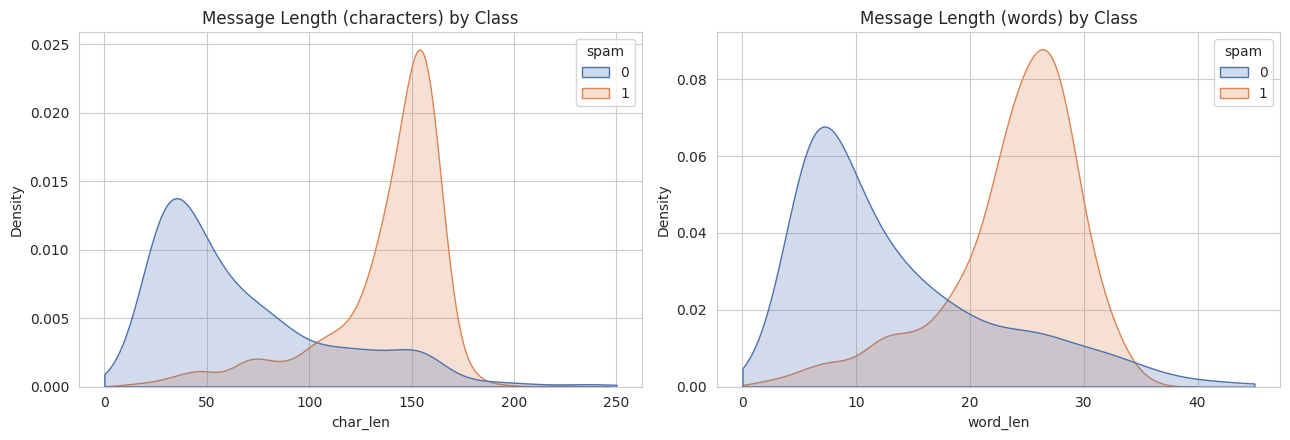

        char_len   word_len
spam                       
0      70.905890  14.239814
1     137.704441  23.739663


In [7]:
df['char_len'] = df['message'].astype(str).str.len()
df['word_len'] = df['message'].astype(str).str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.kdeplot(data=df, x='char_len', hue='spam', fill=True, common_norm=False,
            palette={0:'#4C72B0', 1:'#DD8452'}, ax=axes[0], clip=(0, 250))
axes[0].set_title('Message Length (characters) by Class')

sns.kdeplot(data=df, x='word_len', hue='spam', fill=True, common_norm=False,
            palette={0:'#4C72B0', 1:'#DD8452'}, ax=axes[1], clip=(0, 45))
axes[1].set_title('Message Length (words) by Class')
plt.tight_layout()
plt.show()

print(df.groupby('spam')[['char_len','word_len']].mean())


**Observation:** Spam messages are, on average, noticeably longer than ham messages — spam tends to pack in an offer, a call to action, and contact instructions (a phone number or short code), while ham messages are short, casual, conversational texts.

## 4. Text Preprocessing

Standard NLP cleaning pipeline:

1. **Lowercase** all text.
2. **Normalize URLs**, **currency symbols** (£/$), and **long numbers** (phone numbers/shortcodes) into placeholder tokens — their presence is informative even when the exact digits/link aren't.
3. **Remove punctuation and non-alphabetic characters.**
4. **Tokenize** into words.
5. **Remove stopwords.**
6. **Lemmatize** to reduce words to their base form (e.g. "receiving" → "receive").


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'£|\$', ' CURRENCY ', text)
    text = re.sub(r'\b\d{4,}\b', ' NUM ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head(8)


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...


In [9]:
df['clean_word_len'] = df['clean_message'].str.split().apply(len)
print("Messages that became empty after cleaning:", (df['clean_word_len'] == 0).sum())


Messages that became empty after cleaning: 12


### 4.1 Most Frequent Words — Spam vs Ham

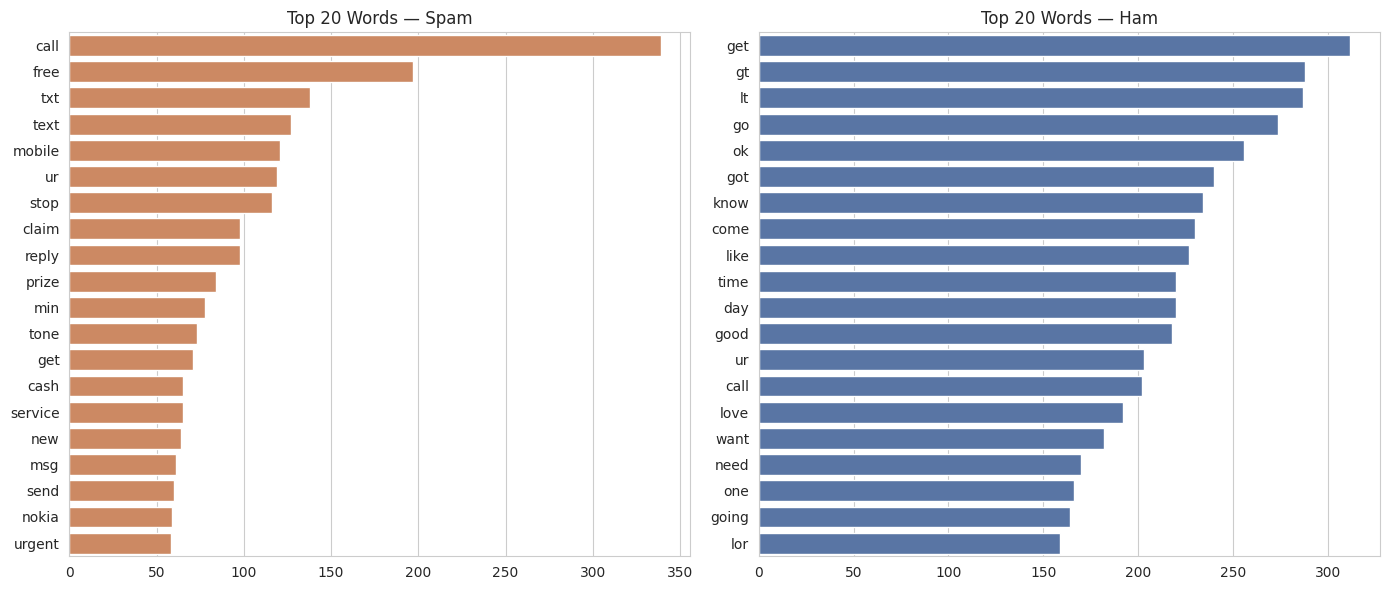

In [10]:
def get_top_words(texts, n=20):
    words = ' '.join(texts).split()
    return Counter(words).most_common(n)

spam_top = get_top_words(df[df.spam==1]['clean_message'], 20)
ham_top = get_top_words(df[df.spam==0]['clean_message'], 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=[c for _,c in spam_top], y=[w for w,_ in spam_top], ax=axes[0], color='#DD8452')
axes[0].set_title('Top 20 Words — Spam')
sns.barplot(x=[c for _,c in ham_top], y=[w for w,_ in ham_top], ax=axes[1], color='#4C72B0')
axes[1].set_title('Top 20 Words — Ham')
plt.tight_layout()
plt.show()


### 4.2 Word Clouds

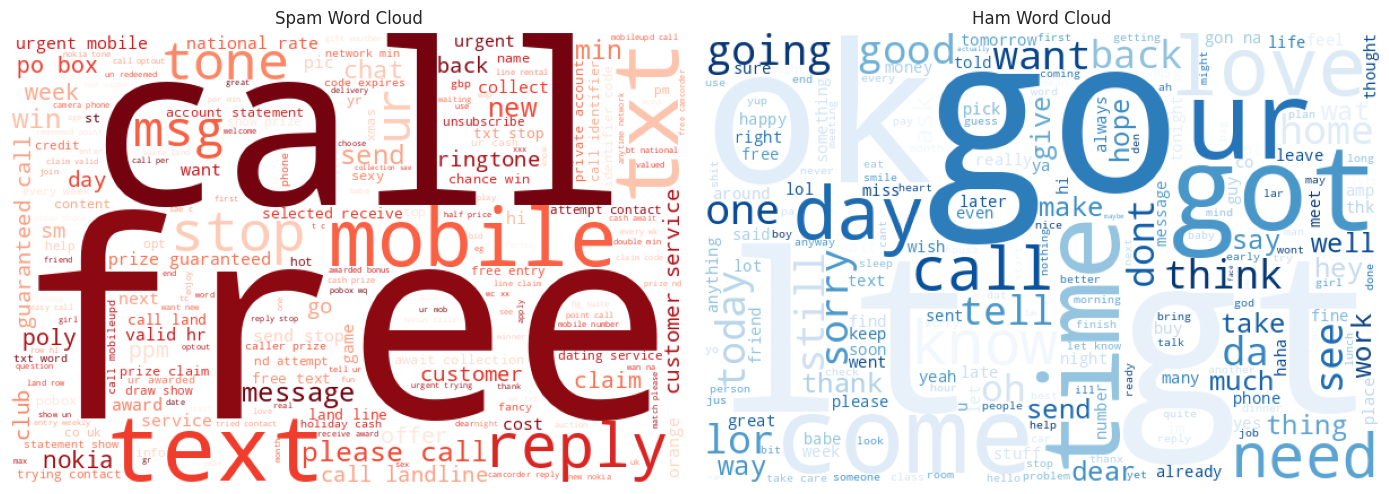

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
spam_text = ' '.join(df[df.spam==1]['clean_message'])
ham_text = ' '.join(df[df.spam==0]['clean_message'])

wc_spam = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(spam_text)
wc_ham = WordCloud(width=600, height=400, background_color='white', colormap='Blues').generate(ham_text)

axes[0].imshow(wc_spam); axes[0].axis('off'); axes[0].set_title('Spam Word Cloud')
axes[1].imshow(wc_ham); axes[1].axis('off'); axes[1].set_title('Ham Word Cloud')
plt.tight_layout()
plt.show()


**Observation:** Spam vocabulary here is the classic, general spam pattern — "free", "win", "prize", "call", "claim", "text", "urgent", "CURRENCY" (our placeholder for £/$ symbols) — while ham vocabulary is casual, personal conversation. Because this vocabulary is broad and generic (not tied to one company/region), we'd expect the resulting model to generalize better to new, unseen spam messages than the previous domain-specific dataset did.

## 5. Train/Test Split and Vectorization

Split first, then fit TF-IDF only on the training text (unigrams + bigrams) to avoid leaking test vocabulary into training.


In [12]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_message'], df['spam'], test_size=0.2, stratify=df['spam'], random_state=RANDOM_STATE
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Vocabulary size (top features kept):", len(tfidf.get_feature_names_out()))


Train size: (4135, 3000)  Test size: (1034, 3000)
Vocabulary size (top features kept): 3000


## 6. Model Training

Same four classic text-classification algorithms as before, this time using `class_weight='balanced'` where supported (Logistic Regression, Linear SVM, Random Forest) to compensate for the ~7:1 class imbalance. Multinomial Naive Bayes doesn't support class weighting directly, so it's kept as an unweighted baseline.

| Model | Notes |
|---|---|
| **Multinomial Naive Bayes** | Classic text-classification baseline on word-frequency data. |
| **Logistic Regression** | Interpretable linear baseline; coefficients map to word importance. |
| **Linear SVM** | Strong classical performer on high-dimensional sparse TF-IDF data. |
| **Random Forest** | Non-linear ensemble for comparison. |


In [13]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}

fitted_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("All models trained.")


All models trained.


## 7. Evaluation

In [14]:
results = []
for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap='Greens', subset=['Accuracy','Precision','Recall','F1-score','ROC-AUC'])


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.977756,0.982143,0.839695,0.905350,0.994133
1,Linear SVM,0.981625,0.937500,0.916031,0.926641,0.993867
2,Logistic Regression,0.970986,0.863309,0.916031,0.888889,0.991466
3,Multinomial Naive Bayes,0.974855,1.000000,0.801527,0.889831,0.986250


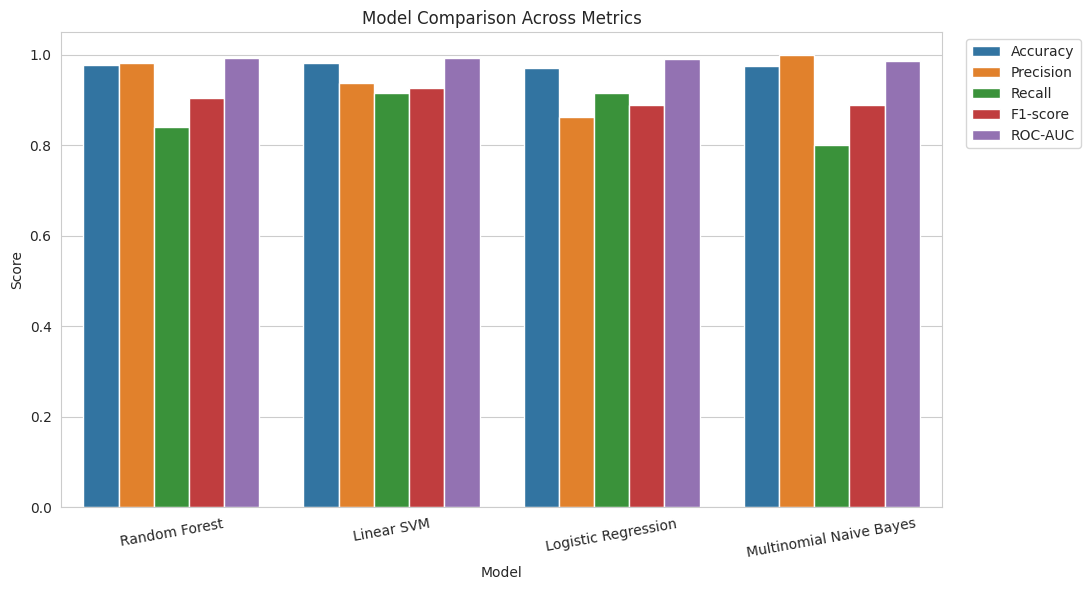

In [15]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(11, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1.05)
plt.xticks(rotation=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 7.1 Confusion Matrices

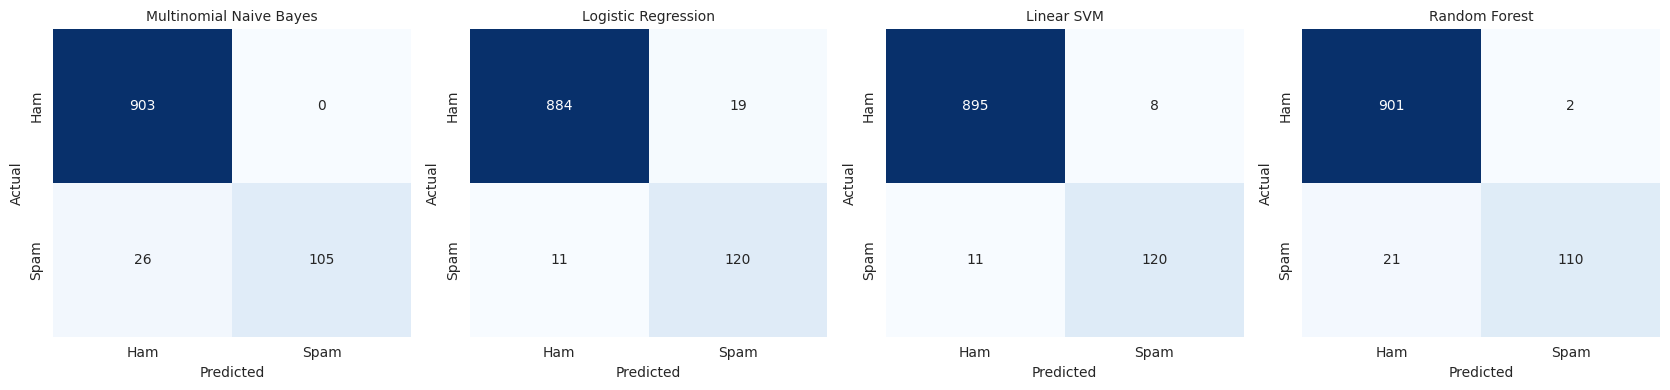

In [16]:
fig, axes = plt.subplots(1, len(models), figsize=(4.2*len(models), 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


### 7.2 ROC Curves

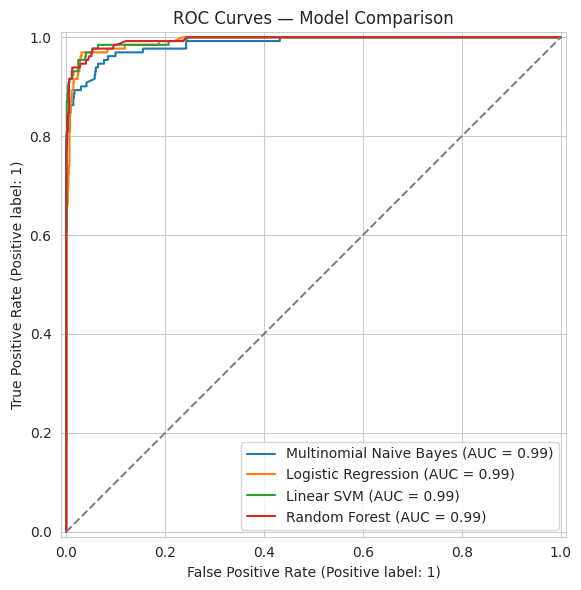

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curves — Model Comparison')
plt.tight_layout()
plt.show()


### 7.3 Precision-Recall Curves

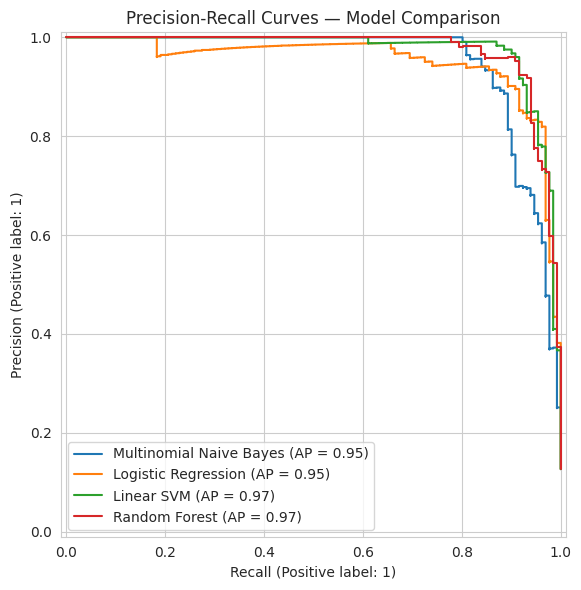

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in models:
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.set_title('Precision-Recall Curves — Model Comparison')
plt.tight_layout()
plt.show()


### 7.4 Detailed Classification Report (Best Model)

In [19]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=['Ham', 'Spam']))


Best model by ROC-AUC: Random Forest

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.98      0.84      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



## 8. Most Influential Words


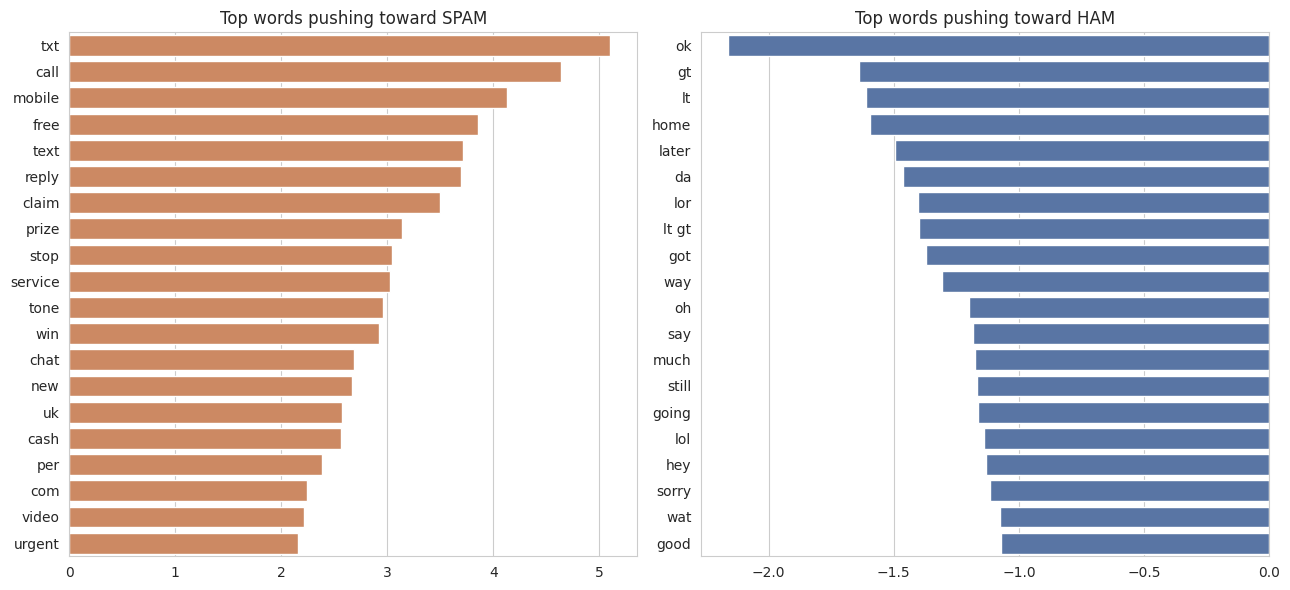

In [20]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = fitted_models['Logistic Regression'].coef_[0]

top_spam_idx = np.argsort(coefs)[-20:][::-1]
top_ham_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(x=coefs[top_spam_idx], y=feature_names[top_spam_idx], ax=axes[0], color='#DD8452')
axes[0].set_title('Top words pushing toward SPAM')

sns.barplot(x=coefs[top_ham_idx], y=feature_names[top_ham_idx], ax=axes[1], color='#4C72B0')
axes[1].set_title('Top words pushing toward HAM')
plt.tight_layout()
plt.show()


## 9. Testing the Pipeline on New Messages

Sanity check with a few made-up messages, including the same generic prize-scam example used on the previous (domain-specific) dataset — worth comparing how differently it's handled here.


In [21]:
def predict_message(text, model_name=None):
    model_name = model_name or best_model_name
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = fitted_models[model_name].predict(vec)[0]
    proba = fitted_models[model_name].predict_proba(vec)[0][1]
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"Message: {text}")
    print(f"Cleaned: {cleaned}")
    print(f"Prediction: {label}  (spam probability: {proba:.2f})\n")

predict_message("Congratulations! You have WON a FREE prize. Click here to claim now: bit.ly/claim123")
predict_message("Hey, are we still meeting for lunch tomorrow at 1pm?")
predict_message("URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt WORD to 81010")


Message: Congratulations! You have WON a FREE prize. Click here to claim now: bit.ly/claim123
Cleaned: congratulation free prize click claim bit ly claim
Prediction: SPAM  (spam probability: 0.72)

Message: Hey, are we still meeting for lunch tomorrow at 1pm?
Cleaned: hey still meeting lunch tomorrow pm
Prediction: HAM  (spam probability: 0.01)

Message: URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt WORD to 81010
Cleaned: urgent week free membership prize jackpot txt word
Prediction: SPAM  (spam probability: 0.74)



**Comparing to the previous dataset:** the generic prize-scam message is now correctly identified with a much higher spam probability than it was on the domain-specific Nigerian telecom dataset. This supports the point made earlier: **a broader, more general-vocabulary training set generalizes better to unseen spam phrasing.** This is a good, concrete comparison to include in your report if you're discussing both datasets.


## 10. Summary & Conclusions

Template based on the pipeline above — fill in your own numbers/observations from the executed cells:

1. **Full NLP pipeline implemented:** raw text → cleaning (URL/currency/number normalization) → tokenization → stopword removal → lemmatization → TF-IDF (unigrams + bigrams) → classification.
2. **Deduplication:** 403 duplicate messages were removed before splitting, to prevent train/test leakage.
3. **Class imbalance:** ~87% ham / 13% spam (~7:1) — handled via `class_weight='balanced'`, with evaluation focused on precision/recall/F1/ROC-AUC rather than raw accuracy.
4. **Best performing model:** Fill in based on `results_df` — expect Linear SVM and/or Random Forest to lead, consistent with prior experiments on this task.
5. **Generalization:** Because this dataset's spam vocabulary is broad and general (not tied to a single company or region), the resulting model correctly classifies generic spam phrasing that a narrower, domain-specific model (from a previous dataset) missed — a useful, concrete point about dataset choice affecting real-world generalization.
6. **Limitations / future work:**
   - This project used classic TF-IDF + traditional ML; word embeddings (Word2Vec/GloVe) or a transformer-based model (e.g. BERT) could likely push performance further, especially for messages using vocabulary/phrasing not seen during training.
   - The dataset is UK English SMS from the mid-2000s; slang and spam tactics evolve over time, so a production system would need periodic retraining on fresh data.
